Sinal original:
[  7.  14.  11.  43.  38.  61.  75.  38.  12.  18.  18.  17.  19.  32.
  42.  57.  44. 114.  35.  11.  13.  10.]

Sinal filtrado manualmente:
[ 3.5 10.5 12.5 27.  40.5 49.5 68.  56.5 25.  15.  18.  17.5 18.  25.5
 37.  49.5 50.5 79.  74.5 23.  12.  11.5]

Sinal filtrado com funcao pronta:
[ 3.5 10.5 12.5 27.  40.5 49.5 68.  56.5 25.  15.  18.  17.5 18.  25.5
 37.  49.5 50.5 79.  74.5 23.  12.  11.5]


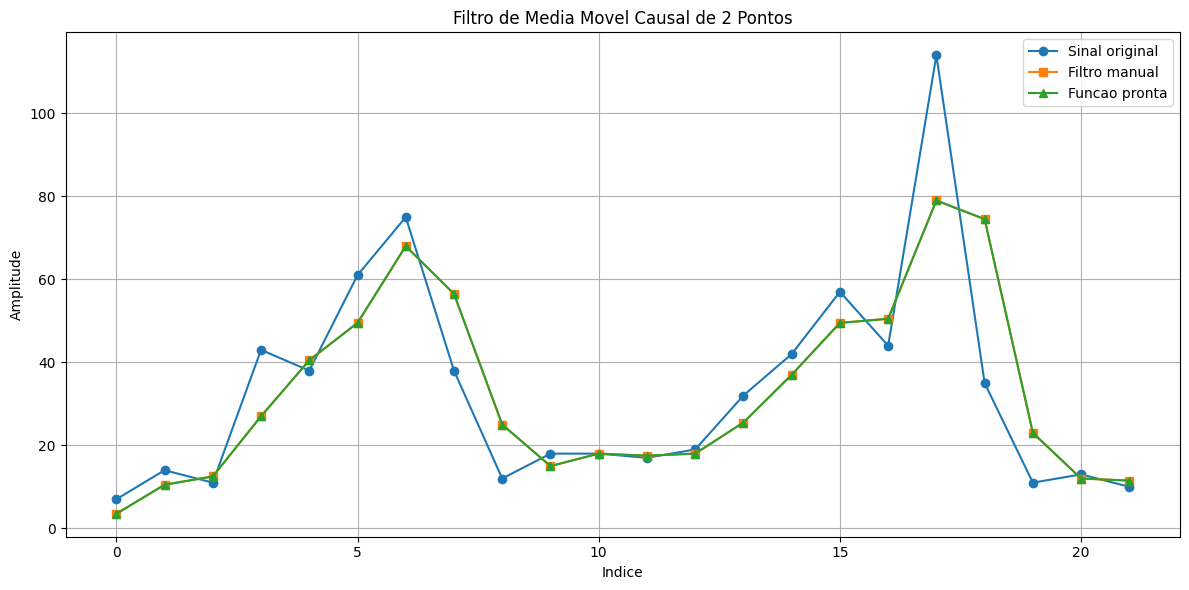

In [13]:
from __future__ import annotations

import matplotlib.pyplot as plt
from collections.abc import Sequence
from typing import Any
import numpy as np

def plot_series(
    series: Sequence[dict[str, Any]],
    title: str,
    xlabel: str,
    ylabel: str,
    figsize: tuple[float, float] = (12, 6),
    grid: bool = True,
    legend: bool = True,
    tight_layout: bool = True,
) -> None:
    """Função que plota um gráfico e aceita mais de 1 elemento"""

    # Cria a figura com o tamanho informado.
    plt.figure(figsize=figsize)

    # Percorre cada serie recebida e desenha tudo no mesmo grafico.
    for item in series:
        x_values = item.get("x")
        y_values = item["y"]
        plot_kwargs = item.get("plot_kwargs", {})

        # Se x nao for informado, o matplotlib usa os indices automaticamente.
        if x_values is None:
            plt.plot(y_values, **plot_kwargs)
        else:
            plt.plot(x_values, y_values, **plot_kwargs)

    # Configuracoes visuais do grafico.
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(grid)

    # Mostra a legenda somente quando ela estiver habilitada.
    if legend:
        plt.legend()

    # Ajusta os espacos para evitar sobreposicao de elementos.
    if tight_layout:
        plt.tight_layout()

    plt.show()


def moving_average_manual(signal):
    """Implementa manualmente a media movel causal y[n] = 0.5x[n] + 0.5x[n-1]."""
    filtered = []

    for i in range(len(signal)):
        current_sample = signal[i]
        # Para n = 0, assume x[n-1] = 0 por causa da condicao inicial nula.
        previous_sample = signal[i - 1] if i > 0 else 0.0
        filtered_value = 0.5 * current_sample + 0.5 * previous_sample
        filtered.append(filtered_value)

    # Converte a lista final para array NumPy.
    return np.array(filtered)


def moving_average_builtin(signal):
    """Aplica a mesma media movel causal usando a convolucao pronta do NumPy"""
    # h[n] = [0.5, 0.5], que corresponde a y[n] = 0.5x[n] + 0.5x[n-1].
    kernel = np.array([0.5, 0.5])
    # Usa a convolucao completa e corta para manter o mesmo tamanho do sinal.
    return np.convolve(signal, kernel, mode="full")[: len(signal)]


def main():
    data = np.array([
        7, 14, 11, 43, 38, 61, 75, 38, 12, 18, 18,
        17, 19, 32, 42, 57, 44, 114, 35, 11, 13, 10,
    ], dtype=np.float32)

    filtered_manual = moving_average_manual(data)
    filtered_builtin = moving_average_builtin(data)

    print("Sinal original:")
    print(data)

    print("\nSinal filtrado manualmente:")
    print(np.round(filtered_manual, 2))

    print("\nSinal filtrado com funcao pronta:")
    print(np.round(filtered_builtin, 2))

    # Plota o sinal original e os dois sinais filtrados para comparacao visual.
    plot_series(
        series=[
            {"y": data, "plot_kwargs": {"marker": "o", "label": "Sinal original"}},
            {"y": filtered_manual, "plot_kwargs": {"marker": "s", "label": "Filtro manual"}},
            {"y": filtered_builtin, "plot_kwargs": {"marker": "^", "label": "Funcao pronta"}},
        ],
        title="Filtro de Media Movel Causal de 2 Pontos",
        xlabel="Indice",
        ylabel="Amplitude",
        figsize=(12, 6),
    )


if __name__ == "__main__":
    main()
